# Evaluate Self-Play Data

This notebook inspects saved self-play outputs for the maintained adversarial pipelines.

Supported formats:
- `flat_meta` from `AlphaZeroMetaAdversarial`
- `factorized_axes` from `AlphaZeroAdversarial`

It focuses on the data-quality aspects that matter before training:
- manifest and shard integrity
- outcome balance and episode length
- sample balance by role
- policy concentration and target-value distribution
- action bias for both flat-meta and factorized policy formats
- target-vector sanity
- spot checks of saved tensors

The first code cell is the only place you usually need to edit:
- set `MANIFEST_PATH` if you want a different manifest
- set `SELECTED_SHARD_PATHS = None` to analyze the full manifest instead of a shard subset


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

try:
    from IPython.display import display
except ModuleNotFoundError:
    def display(value):
        print(value)

plt.style.use("ggplot")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 200)

ROOT = Path.cwd().resolve()
if not (ROOT / "source").exists():
    candidate_roots = [
        Path("/home/namph32/workspace/Autonomous-Driving-Gym"),
        Path("/home/fannam/workspace/Autonomous-Driving-Gym"),
    ]
    ROOT = next((candidate.resolve() for candidate in candidate_roots if candidate.exists()), ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from notebooks.analysis.evaluate_self_play_data_support import (
    META_ACTION_LABELS,
    analyze_manifest,
    resolve_manifest_path,
    summarize_manifest,
)

ANALYSIS_DIR = ROOT / "notebooks/analysis"
SEARCH_ROOTS = [
    ANALYSIS_DIR,
    ROOT / "source/AlphaZero-meta-adversarial-autonomous-driving/outputs/self_play",
    ROOT / "source/AlphaZero-adversarial-autonomous-driving/outputs/self_play",
    ROOT / "outputs",
    Path("/kaggle/working/meta_self_play_machine_1"),
    Path("/kaggle/working/alphazero_meta_adversarial_self_play"),
    Path("/kaggle/working/alphazero_adversarial_self_play"),
]
MANIFEST_PATH: str | None = str(ANALYSIS_DIR / "manifest.json") if (ANALYSIS_DIR / "manifest.json").exists() else None
DEFAULT_SELECTED_SHARD_PATHS = sorted(
    ANALYSIS_DIR.glob("global_worker_*_local_worker_*_shard_*.pt")
)
SELECTED_SHARD_PATHS: list[str] | None = [str(path) for path in DEFAULT_SELECTED_SHARD_PATHS if path.exists()] or None
STATE_SAMPLE_INDEX = 0

ROOT


PosixPath('/home/namph32/workspace/Autonomous-Driving-Gym')

In [2]:
manifest_path = resolve_manifest_path(MANIFEST_PATH, SEARCH_ROOTS)
selected_shard_names = [Path(path).name for path in SELECTED_SHARD_PATHS] if SELECTED_SHARD_PATHS else None
analysis = analyze_manifest(
    manifest_path,
    shard_search_roots=SEARCH_ROOTS,
    selected_shard_names=selected_shard_names,
)

manifest = analysis["manifest"]
policy_format = analysis["policy_format"]
factorized_axis_info = analysis["factorized_axis_info"]
shard_df = analysis["shard_df"]
episode_df = analysis["episode_df"]
sample_df = analysis["sample_df"]
target_stats_df = analysis["target_stats_df"]
analysis_scope = "selected_shards" if selected_shard_names else "full_manifest"

display(
    pd.DataFrame(
        [
            {
                "analysis_scope": analysis_scope,
                "manifest_path": str(manifest_path),
                "loaded_shards": int(shard_df.shape[0]),
                "loaded_samples": int(sample_df.shape[0]),
                "loaded_episodes": int(episode_df.shape[0]),
            }
        ]
    )
)
if selected_shard_names:
    display(pd.DataFrame({"selected_shard_name": selected_shard_names}))
display(summarize_manifest(analysis))
display(pd.DataFrame([manifest.get("args", {})]).T.rename(columns={0: "value"}).head(30))
display(shard_df.head(10))
display(episode_df.head(10))
print(f"policy_format={policy_format}")


,analysis_scope,manifest_path,loaded_shards,loaded_samples,loaded_episodes
0,selected_shards,/home/namph32/workspace/Autonomous-Driving-Gym...,8,1139,16


,selected_shard_name
0,global_worker_00008_local_worker_00_shard_000.pt
1,global_worker_00009_local_worker_01_shard_000.pt
2,global_worker_00010_local_worker_02_shard_000.pt
3,global_worker_00011_local_worker_03_shard_000.pt
4,global_worker_00012_local_worker_04_shard_000.pt
5,global_worker_00013_local_worker_05_shard_000.pt
6,global_worker_00014_local_worker_06_shard_000.pt
7,global_worker_00015_local_worker_07_shard_000.pt


,manifest_path,active_scenario,env_id,manifest_kind,policy_format,total_shards_manifest,total_shards_loaded,total_samples_manifest,total_samples_loaded,total_episodes_loaded
0,/home/namph32/workspace/Autonomous-Driving-Gym...,highway_meta_adversarial,highway-v0,multi_worker,flat_meta,8,8,1139,1139,16


,value
workers,8
episodes_per_worker,2
total_episodes,None
episodes_per_shard,5
self_play_seed,1000
env_seed,10
network_seed,42
model_path,/kaggle/input/datasets/nam080/highway-v0-meta-...
output_dir,/kaggle/working/meta_self_play_machine_1
device,cuda


,path,shard_name,manifest_kind,worker_id,global_worker_id,shard_index,policy_format,episode_count,sample_count,episode_sample_count_sum,state_shape,target_shape,value_shape,state_nonfinite,target_nonfinite,value_nonfinite,ego_samples,npc_samples,unknown_role_samples,value_min,value_max,policy_shape,policy_nonfinite,policy_row_sum_min,policy_row_sum_max
0,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00008_local_worker_00_shard_000.pt,multi_worker,0,8,0,flat_meta,2,94,94,"(94, 17, 100, 24)","(94, 8)","(94, 1)",0,0,0,47,47,0,-1.0,1.0,"(94, 5)",0,1.0,1.0
1,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00009_local_worker_01_shard_000.pt,multi_worker,1,9,0,flat_meta,2,84,84,"(84, 17, 100, 24)","(84, 8)","(84, 1)",0,0,0,42,42,0,-1.0,1.0,"(84, 5)",0,1.0,1.0
2,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00010_local_worker_02_shard_000.pt,multi_worker,2,10,0,flat_meta,2,160,160,"(160, 17, 100, 24)","(160, 8)","(160, 1)",0,0,0,80,80,0,-1.0,1.0,"(160, 5)",0,1.0,1.0
3,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00011_local_worker_03_shard_000.pt,multi_worker,3,11,0,flat_meta,2,160,160,"(160, 17, 100, 24)","(160, 8)","(160, 1)",0,0,0,80,80,0,-1.0,1.0,"(160, 5)",0,1.0,1.0
4,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00012_local_worker_04_shard_000.pt,multi_worker,4,12,0,flat_meta,2,160,160,"(160, 17, 100, 24)","(160, 8)","(160, 1)",0,0,0,80,80,0,-1.0,1.0,"(160, 5)",0,1.0,1.0
5,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00013_local_worker_05_shard_000.pt,multi_worker,5,13,0,flat_meta,2,161,161,"(161, 17, 100, 24)","(161, 8)","(161, 1)",0,0,0,81,80,0,-1.0,1.0,"(161, 5)",0,1.0,1.0
6,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00014_local_worker_06_shard_000.pt,multi_worker,6,14,0,flat_meta,2,160,160,"(160, 17, 100, 24)","(160, 8)","(160, 1)",0,0,0,80,80,0,-1.0,1.0,"(160, 5)",0,1.0,1.0
7,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00015_local_worker_07_shard_000.pt,multi_worker,7,15,0,flat_meta,2,160,160,"(160, 17, 100, 24)","(160, 8)","(160, 1)",0,0,0,80,80,0,-1.0,1.0,"(160, 5)",0,1.0,1.0


,seed,env_seed,episode_index,steps,outcome_reason,ego_value,npc_value,policy_modes,collected_samples,sample_count,device,global_worker_id,elapsed_s,path,shard_name,worker_id,shard_index,policy_format,policy_modes_label,sample_start,sample_end,ego_samples,npc_samples,unknown_role_samples
0,8001000,8000010,0,40,ego_timeout_safe,1.0,-1.0,"(None, None)",80,80,cuda:0,8,4730.570707,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00008_local_worker_00_shard_000.pt,0,0,flat_meta,"(None, None)",0,80,40,40,0
1,8001001,8000011,1,7,ego_self_collision,-1.0,0.0,"(None, None)",14,14,cuda:0,8,680.497679,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00008_local_worker_00_shard_000.pt,0,0,flat_meta,"(None, None)",80,94,7,7,0
2,9001000,9000010,2,2,ego_self_collision,-1.0,0.0,"(None, None)",4,4,cuda:1,9,126.767875,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00009_local_worker_01_shard_000.pt,1,0,flat_meta,"(None, None)",0,4,2,2,0
3,9001001,9000011,3,40,ego_timeout_safe,1.0,-1.0,"(None, None)",80,80,cuda:1,9,4824.631481,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00009_local_worker_01_shard_000.pt,1,0,flat_meta,"(None, None)",4,84,40,40,0
4,10001000,10000010,4,40,ego_timeout_safe,1.0,-1.0,"(None, None)",80,80,cuda:0,10,4768.514548,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00010_local_worker_02_shard_000.pt,2,0,flat_meta,"(None, None)",0,80,40,40,0
5,10001001,10000011,5,40,ego_timeout_safe,1.0,-1.0,"(None, None)",80,80,cuda:0,10,3689.678426,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00010_local_worker_02_shard_000.pt,2,0,flat_meta,"(None, None)",80,160,40,40,0
6,11001000,11000010,6,40,ego_timeout_safe,1.0,-1.0,"(None, None)",80,80,cuda:1,11,4629.370188,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00011_local_worker_03_shard_000.pt,3,0,flat_meta,"(None, None)",0,80,40,40,0
7,11001001,11000011,7,40,ego_timeout_safe,1.0,-1.0,"(None, None)",80,80,cuda:1,11,3828.111036,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00011_local_worker_03_shard_000.pt,3,0,flat_meta,"(None, None)",80,160,40,40,0
8,12001000,12000010,8,40,ego_timeout_safe,1.0,-1.0,"(None, None)",80,80,cuda:0,12,4695.427784,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00012_local_worker_04_shard_000.pt,4,0,flat_meta,"(None, None)",0,80,40,40,0
9,12001001,12000011,9,40,ego_timeout_safe,1.0,-1.0,"(None, None)",80,80,cuda:0,12,3734.841608,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00012_local_worker_04_shard_000.pt,4,0,flat_meta,"(None, None)",80,160,40,40,0


policy_format=flat_meta


,outcome_reason,episodes
0,ego_timeout_safe,14
1,ego_self_collision,2


,policy_modes_label,episodes
0,"(None, None)",16


,count,mean,std,min,25%,50%,75%,max
steps,16.0,35.625000,12.186741,2.000000,40.000000,40.000000,40.000000,41.000000
sample_count,16.0,71.187500,24.345345,4.000000,80.000000,80.000000,80.000000,81.000000
ego_samples,16.0,35.625000,12.186741,2.000000,40.000000,40.000000,40.000000,41.000000
npc_samples,16.0,35.562500,12.159873,2.000000,40.000000,40.000000,40.000000,40.000000
elapsed_s,16.0,3815.699843,1424.205661,126.767875,3682.985954,4228.740612,4740.056667,4824.631481
ego_value,16.0,0.750000,0.683130,-1.000000,1.000000,1.000000,1.000000,1.000000
npc_value,16.0,-0.875000,0.341565,-1.000000,-1.000000,-1.000000,-1.000000,0.000000


steps                   sample_count                   ego_samples                   npc_samples              elapsed_s                           ego_value             npc_value  \
                   count       mean median        count       mean median       count       mean median       count  mean median     count         mean       median     count mean median     count   
outcome_reason                                                                                                                                                                                         
ego_timeout_safe      14  40.071429   40.0           14  80.071429   80.0          14  40.071429   40.0          14  40.0   40.0        14  4303.137995  4662.398986        14  1.0    1.0        14   
ego_self_collision     2   4.500000    4.5            2   9.000000    9.0           2   4.500000    4.5           2   4.5    4.5         2   403.632777   403.632777         2 -1.0   -1.0         2   

                                
                   mean median  
outcome_reason                  
ego_timeout_safe   -1.0   -1.0  
ego_self_collision  0.0    0.0

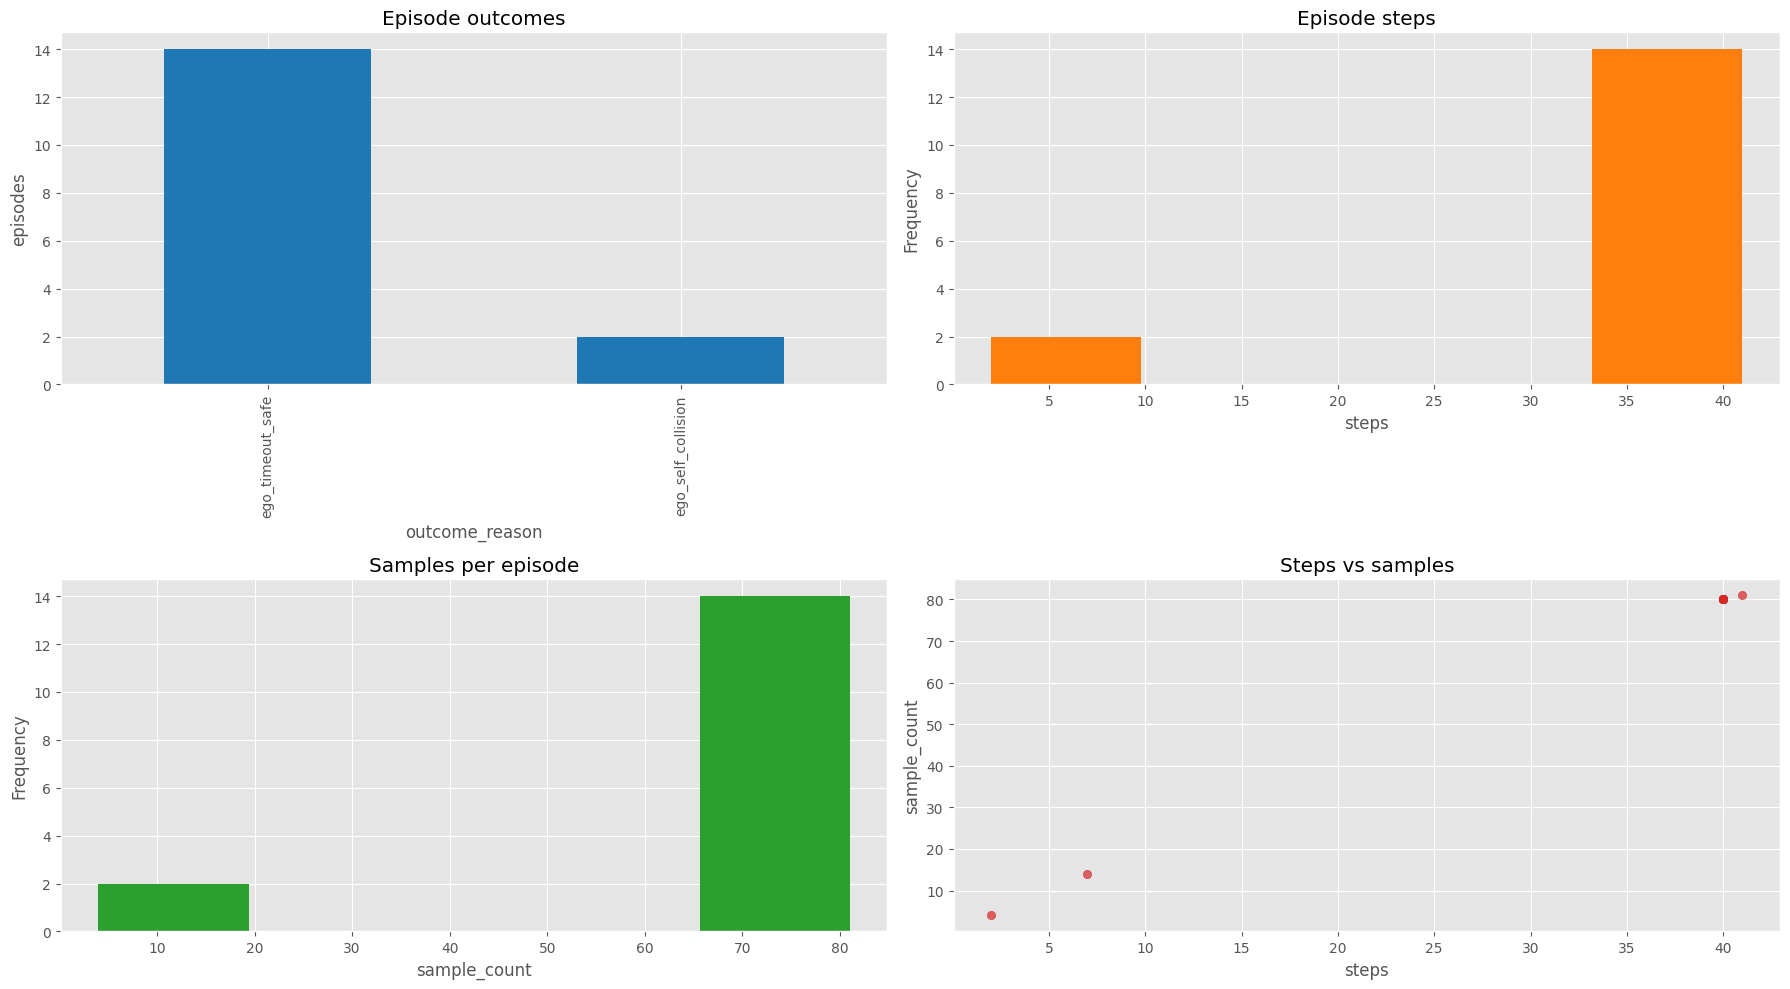

In [3]:
outcome_counts = (
    episode_df["outcome_reason"]
    .value_counts(dropna=False)
    .rename_axis("outcome_reason")
    .reset_index(name="episodes")
)
policy_mode_counts = (
    episode_df["policy_modes_label"]
    .value_counts(dropna=False)
    .rename_axis("policy_modes_label")
    .reset_index(name="episodes")
)
episode_numeric_cols = [
    column
    for column in ["steps", "sample_count", "ego_samples", "npc_samples", "elapsed_s", "ego_value", "npc_value"]
    if column in episode_df.columns
]

display(outcome_counts)
display(policy_mode_counts)
display(episode_df[episode_numeric_cols].describe().T)
display(
    episode_df.groupby("outcome_reason")[episode_numeric_cols]
    .agg(["count", "mean", "median"])
    .sort_values((episode_numeric_cols[0], "count"), ascending=False)
)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
outcome_counts.plot.bar(x="outcome_reason", y="episodes", ax=axes[0, 0], legend=False, color="tab:blue")
axes[0, 0].set_title("Episode outcomes")
axes[0, 0].set_xlabel("outcome_reason")
axes[0, 0].set_ylabel("episodes")

episode_df["steps"].plot.hist(
    bins=min(30, max(5, int(episode_df["steps"].nunique()))),
    ax=axes[0, 1],
    color="tab:orange",
)
axes[0, 1].set_title("Episode steps")
axes[0, 1].set_xlabel("steps")

episode_df["sample_count"].plot.hist(
    bins=min(30, max(5, int(episode_df["sample_count"].nunique()))),
    ax=axes[1, 0],
    color="tab:green",
)
axes[1, 0].set_title("Samples per episode")
axes[1, 0].set_xlabel("sample_count")

axes[1, 1].scatter(episode_df["steps"], episode_df["sample_count"], alpha=0.7, color="tab:red")
axes[1, 1].set_title("Steps vs samples")
axes[1, 1].set_xlabel("steps")
axes[1, 1].set_ylabel("sample_count")

plt.tight_layout()
plt.show()


In [4]:
role_counts = (
    sample_df["role"]
    .value_counts(dropna=False)
    .rename_axis("role")
    .reset_index(name="samples")
)
sample_summary_cols = ["policy_entropy", "max_policy_prob", "value"]
for optional_column in ["accelerate_entropy", "steering_entropy"]:
    if optional_column in sample_df.columns:
        sample_summary_cols.append(optional_column)
sample_summary = (
    sample_df.groupby("role")[sample_summary_cols]
    .agg(["count", "mean", "median", "std"])
    .sort_index()
)

display(role_counts)
display(sample_summary)
display(target_stats_df)


,role,samples
0,ego,570
1,npc,569


policy_entropy                                   max_policy_prob                            value                              
              count      mean        median       std           count      mean median       std count      mean    median       std
role                                                                                                                                
ego             570  0.438280  1.105241e-10  0.555620             570  0.800197    1.0  0.261185   570  0.798816  0.817907  0.244373
npc             569  0.455982  1.105241e-10  0.564351             569  0.794016    1.0  0.261752   569 -0.814481 -0.817907  0.140513

,role,sample_count,dx_mean,dx_std,dy_mean,dy_std,dvx_mean,dvx_std,dvy_mean,dvy_std,sin_bearing_mean,sin_bearing_std,cos_bearing_mean,cos_bearing_std,role_bit_mean,role_bit_std,target_type_bit_mean,target_type_bit_std
0,ego,570,0.546405,0.017132,0.000631,0.024132,-0.001109,0.009119,0.000805,0.027272,0.000988,0.039912,0.999202,0.000931,1.0,0.0,1.0,0.0
1,npc,569,-0.963067,0.051930,0.049352,0.165137,-0.010114,0.084292,0.001013,0.038673,0.021106,0.073694,-0.997048,0.004259,-1.0,0.0,-1.0,0.0


,role,idle_argmax_rate
0,ego,0.326316
1,npc,0.260105


action_label,LANE_LEFT,IDLE,LANE_RIGHT,FASTER,SLOWER
role,,,,,
ego,0.233333,0.326316,0.229825,0.080702,0.129825
npc,0.212654,0.260105,0.228471,0.119508,0.179262


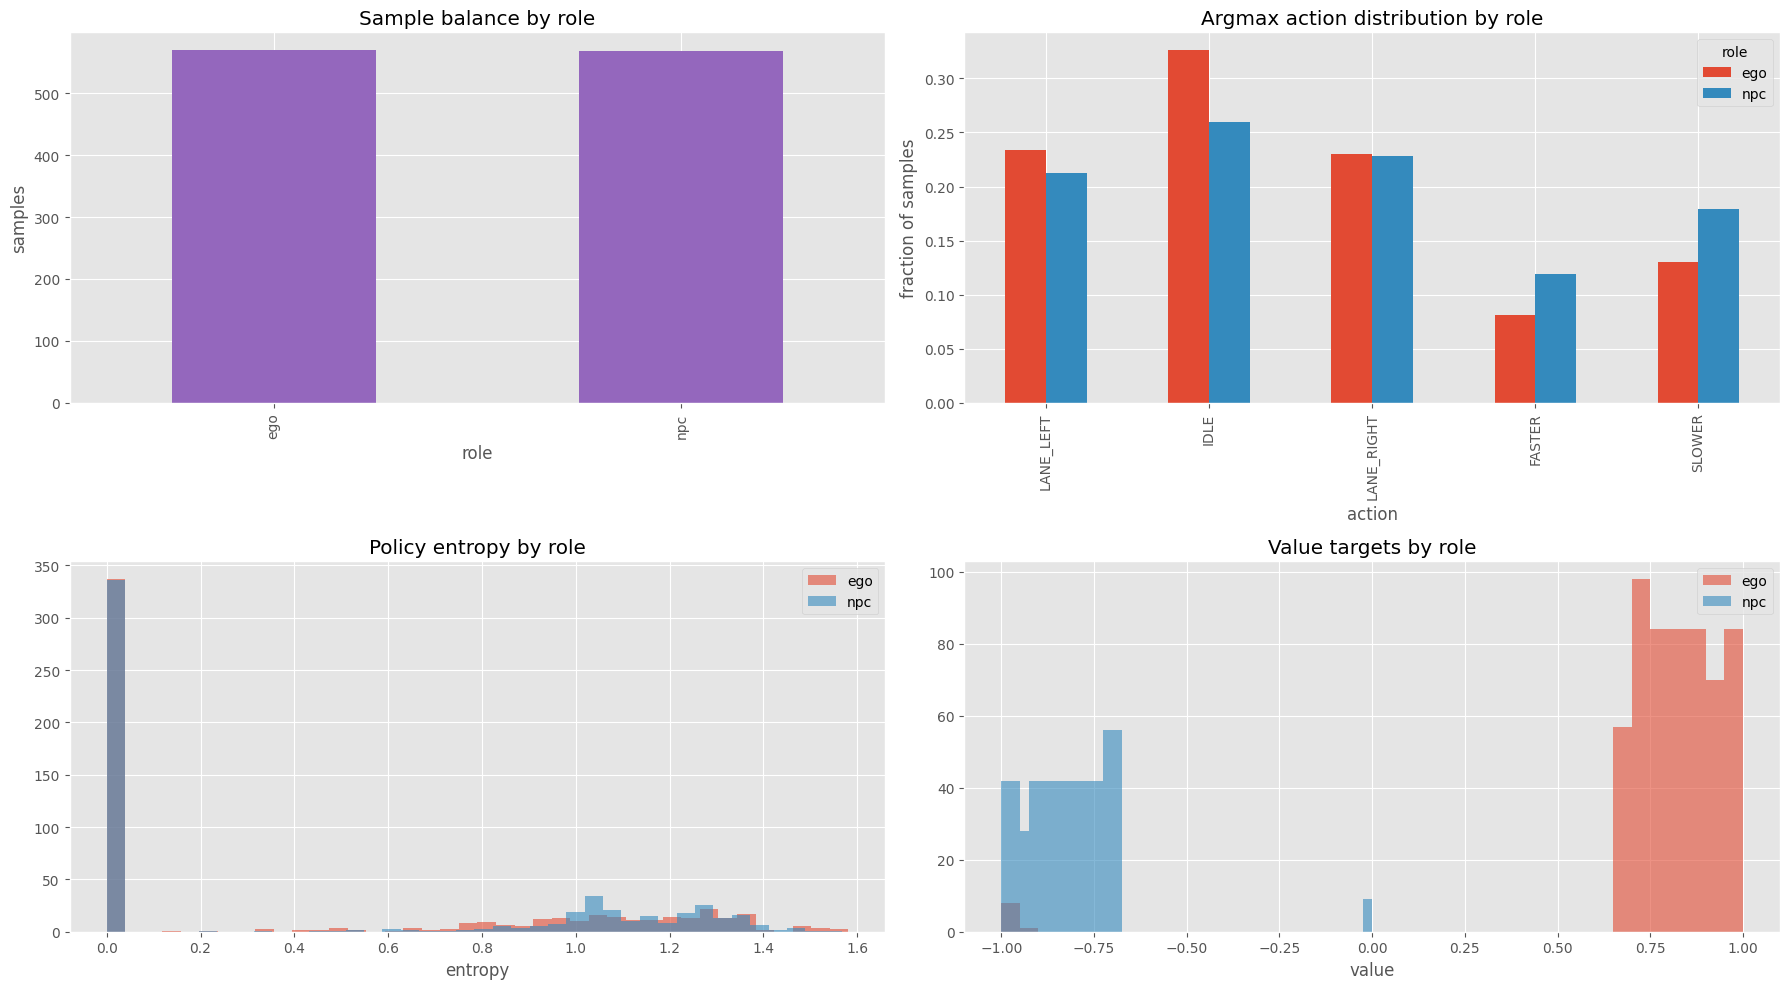

In [5]:
if policy_format == "flat_meta":
    action_distribution = pd.crosstab(
        sample_df["role"],
        sample_df["action_label"],
        normalize="index",
    ).reindex(columns=list(META_ACTION_LABELS.values()), fill_value=0.0)
    idle_rate = (
        sample_df.assign(is_idle=sample_df["action_label"].eq("IDLE"))
        .groupby("role")["is_idle"]
        .mean()
        .rename("idle_argmax_rate")
        .reset_index()
    )

    display(idle_rate)
    display(action_distribution)

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    role_counts.plot.bar(x="role", y="samples", ax=axes[0, 0], legend=False, color="tab:purple")
    axes[0, 0].set_title("Sample balance by role")
    axes[0, 0].set_xlabel("role")
    axes[0, 0].set_ylabel("samples")

    action_distribution.T.plot.bar(ax=axes[0, 1])
    axes[0, 1].set_title("Argmax action distribution by role")
    axes[0, 1].set_xlabel("action")
    axes[0, 1].set_ylabel("fraction of samples")

    for role_name, frame in sample_df.groupby("role"):
        axes[1, 0].hist(frame["policy_entropy"], bins=40, alpha=0.6, label=role_name)
    axes[1, 0].set_title("Policy entropy by role")
    axes[1, 0].set_xlabel("entropy")
    axes[1, 0].legend()

    for role_name, frame in sample_df.groupby("role"):
        axes[1, 1].hist(frame["value"], bins=40, alpha=0.6, label=role_name)
    axes[1, 1].set_title("Value targets by role")
    axes[1, 1].set_xlabel("value")
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

elif policy_format == "factorized_axes":
    axis_0_labels = factorized_axis_info["axis_0_labels"]
    axis_1_labels = factorized_axis_info["axis_1_labels"]
    accelerate_distribution = pd.crosstab(
        sample_df["role"],
        sample_df["accelerate_action_label"],
        normalize="index",
    ).reindex(columns=axis_0_labels, fill_value=0.0)
    steering_distribution = pd.crosstab(
        sample_df["role"],
        sample_df["steering_action_label"],
        normalize="index",
    ).reindex(columns=axis_1_labels, fill_value=0.0)
    center_joint_rate = (
        sample_df.groupby("role")["is_center_joint"]
        .mean()
        .rename("center_joint_rate")
        .reset_index()
    )
    top_joint_actions = (
        sample_df["action_label"]
        .value_counts(dropna=False)
        .rename_axis("joint_argmax_action")
        .reset_index(name="samples")
        .head(20)
    )

    display(center_joint_rate)
    display(accelerate_distribution)
    display(steering_distribution)
    display(top_joint_actions)

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    role_counts.plot.bar(x="role", y="samples", ax=axes[0, 0], legend=False, color="tab:purple")
    axes[0, 0].set_title("Sample balance by role")
    axes[0, 0].set_xlabel("role")
    axes[0, 0].set_ylabel("samples")

    accelerate_distribution.T.plot.bar(ax=axes[0, 1])
    axes[0, 1].set_title("Argmax accelerate distribution by role")
    axes[0, 1].set_xlabel("accelerate bin")
    axes[0, 1].set_ylabel("fraction of samples")

    steering_distribution.T.plot.bar(ax=axes[1, 0])
    axes[1, 0].set_title("Argmax steering distribution by role")
    axes[1, 0].set_xlabel("steering bin")
    axes[1, 0].set_ylabel("fraction of samples")

    for role_name, frame in sample_df.groupby("role"):
        axes[1, 1].hist(frame["value"], bins=40, alpha=0.6, label=role_name)
    axes[1, 1].set_title("Value targets by role")
    axes[1, 1].set_xlabel("value")
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

    heatmap_roles = ["all"] + [role_name for role_name in ["ego", "npc"] if role_name in set(sample_df["role"])]
    fig, axes = plt.subplots(1, len(heatmap_roles), figsize=(6 * len(heatmap_roles), 5), squeeze=False)
    color_image = None
    for axis, role_name in zip(axes[0], heatmap_roles):
        frame = sample_df if role_name == "all" else sample_df[sample_df["role"] == role_name]
        heatmap = pd.crosstab(
            frame["accelerate_action_label"],
            frame["steering_action_label"],
        ).reindex(index=axis_0_labels, columns=axis_1_labels, fill_value=0)
        color_image = axis.imshow(heatmap.to_numpy(), aspect="auto", cmap="viridis")
        axis.set_title(f"Joint argmax heatmap: {role_name}")
        axis.set_xlabel("steering bin")
        axis.set_ylabel("accelerate bin")
        axis.set_xticks(range(len(axis_1_labels)))
        axis.set_xticklabels(axis_1_labels, rotation=45, ha="right")
        axis.set_yticks(range(len(axis_0_labels)))
        axis.set_yticklabels(axis_0_labels)
    if color_image is not None:
        fig.colorbar(color_image, ax=axes.ravel().tolist(), shrink=0.8)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for role_name, frame in sample_df.groupby("role"):
        axes[0].hist(frame["policy_entropy"], bins=40, alpha=0.6, label=role_name)
        axes[1].hist(frame["accelerate_entropy"], bins=40, alpha=0.4, label=f"{role_name}:accelerate")
        axes[1].hist(frame["steering_entropy"], bins=40, alpha=0.4, label=f"{role_name}:steering")
    axes[0].set_title("Joint policy entropy by role")
    axes[0].set_xlabel("entropy")
    axes[0].legend()
    axes[1].set_title("Axis entropy by role")
    axes[1].set_xlabel("entropy")
    axes[1].legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

else:
    print(f"Unsupported or mixed policy format for plotting: {policy_format}")


Sanity checks
  analysis scope                               : selected_shards
  expected total_samples                       : 1139
  loaded total_samples                         : 1139
  expected total_samples matches loaded shards : True
  episode sample_count matches collected_samples: True
  policy rows sum to 1 within tolerance        : True
  value targets stay in [-1, 1]                : True


,path,shard_name,manifest_kind,worker_id,global_worker_id,shard_index,policy_format,episode_count,sample_count,episode_sample_count_sum,state_shape,target_shape,value_shape,state_nonfinite,target_nonfinite,value_nonfinite,ego_samples,npc_samples,unknown_role_samples,value_min,value_max,policy_shape,policy_nonfinite,policy_row_sum_min,policy_row_sum_max
0,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00008_local_worker_00_shard_000.pt,multi_worker,0,8,0,flat_meta,2,94,94,"(94, 17, 100, 24)","(94, 8)","(94, 1)",0,0,0,47,47,0,-1.0,1.0,"(94, 5)",0,1.0,1.0
1,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00009_local_worker_01_shard_000.pt,multi_worker,1,9,0,flat_meta,2,84,84,"(84, 17, 100, 24)","(84, 8)","(84, 1)",0,0,0,42,42,0,-1.0,1.0,"(84, 5)",0,1.0,1.0
2,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00010_local_worker_02_shard_000.pt,multi_worker,2,10,0,flat_meta,2,160,160,"(160, 17, 100, 24)","(160, 8)","(160, 1)",0,0,0,80,80,0,-1.0,1.0,"(160, 5)",0,1.0,1.0
3,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00011_local_worker_03_shard_000.pt,multi_worker,3,11,0,flat_meta,2,160,160,"(160, 17, 100, 24)","(160, 8)","(160, 1)",0,0,0,80,80,0,-1.0,1.0,"(160, 5)",0,1.0,1.0
4,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00012_local_worker_04_shard_000.pt,multi_worker,4,12,0,flat_meta,2,160,160,"(160, 17, 100, 24)","(160, 8)","(160, 1)",0,0,0,80,80,0,-1.0,1.0,"(160, 5)",0,1.0,1.0
5,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00013_local_worker_05_shard_000.pt,multi_worker,5,13,0,flat_meta,2,161,161,"(161, 17, 100, 24)","(161, 8)","(161, 1)",0,0,0,81,80,0,-1.0,1.0,"(161, 5)",0,1.0,1.0
6,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00014_local_worker_06_shard_000.pt,multi_worker,6,14,0,flat_meta,2,160,160,"(160, 17, 100, 24)","(160, 8)","(160, 1)",0,0,0,80,80,0,-1.0,1.0,"(160, 5)",0,1.0,1.0
7,/home/namph32/workspace/Autonomous-Driving-Gym...,global_worker_00015_local_worker_07_shard_000.pt,multi_worker,7,15,0,flat_meta,2,160,160,"(160, 17, 100, 24)","(160, 8)","(160, 1)",0,0,0,80,80,0,-1.0,1.0,"(160, 5)",0,1.0,1.0


State viewer: shard=global_worker_00008_local_worker_00_shard_000.pt sample_index=0 sample_state_shape=(17, 100, 24)


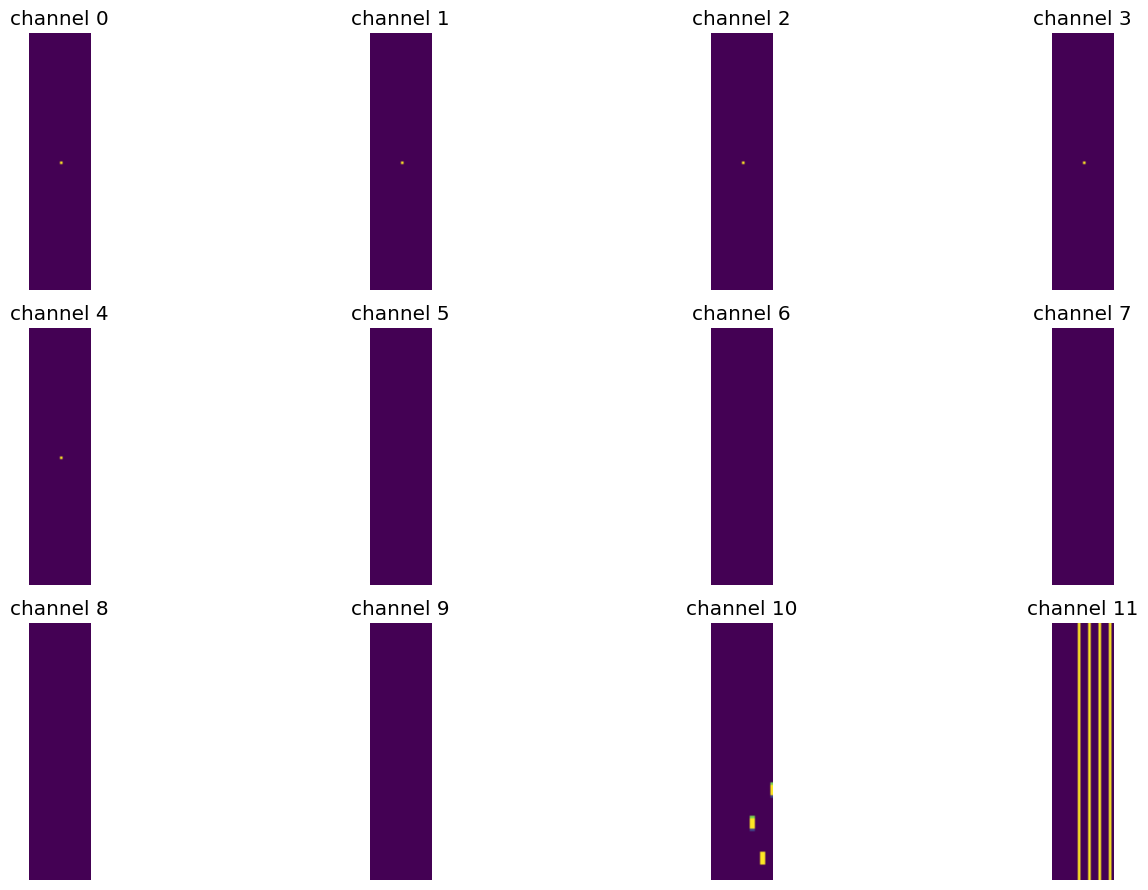

target_vector: [0.57167 0.      0.      0.      0.      1.      1.      1.     ]
policy: [0.         0.20080322 0.3815261  0.2248996  0.19277108]
value: 0.67572904


In [6]:
expected_total_samples = (
    int(shard_df["sample_count"].sum())
    if analysis_scope == "selected_shards"
    else int(manifest.get("total_samples", shard_df["sample_count"].sum()))
)
loaded_total_samples = int(shard_df["sample_count"].sum())
sample_count_matches = expected_total_samples == loaded_total_samples
episode_sample_match = bool((episode_df["sample_count"] == episode_df["collected_samples"]).all()) if "collected_samples" in episode_df.columns else True
policy_rows_close = bool(np.allclose(sample_df["policy_row_sum"].to_numpy(), 1.0, atol=1e-4)) if not sample_df.empty else True
value_range_ok = bool(sample_df["value"].between(-1.0001, 1.0001).all()) if not sample_df.empty else True

print("Sanity checks")
print(f"  analysis scope                               : {analysis_scope}")
print(f"  expected total_samples                       : {expected_total_samples}")
print(f"  loaded total_samples                         : {loaded_total_samples}")
print(f"  expected total_samples matches loaded shards : {sample_count_matches}")
print(f"  episode sample_count matches collected_samples: {episode_sample_match}")
print(f"  policy rows sum to 1 within tolerance        : {policy_rows_close}")
print(f"  value targets stay in [-1, 1]                : {value_range_ok}")

display(shard_df)

first_shard_path = Path(shard_df.iloc[0]["path"])
payload = torch.load(first_shard_path, map_location="cpu")
states = payload["states"].detach().cpu().numpy()
target_vectors = payload["target_vectors"].detach().cpu().numpy()
values = payload["values"].detach().cpu().numpy().reshape(-1)

if len(states) == 0:
    print(f"No samples available in first shard: {first_shard_path}")
else:
    sample_index = int(np.clip(STATE_SAMPLE_INDEX, 0, len(states) - 1))
    sample_state = states[sample_index]
    sample_target = target_vectors[sample_index] if len(target_vectors) else np.array([])
    sample_value = values[sample_index] if len(values) else np.nan

    print(
        f"State viewer: shard={first_shard_path.name} sample_index={sample_index} "
        f"sample_state_shape={sample_state.shape}"
    )
    channel_limit = min(sample_state.shape[0], 12)
    cols = 4
    rows = int(np.ceil(channel_limit / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
    axes = np.asarray(axes).reshape(-1)
    for channel_index in range(channel_limit):
        axes[channel_index].imshow(sample_state[channel_index], cmap="viridis")
        axes[channel_index].set_title(f"channel {channel_index}")
        axes[channel_index].axis("off")
    for axis in axes[channel_limit:]:
        axis.axis("off")
    plt.tight_layout()
    plt.show()

    print("target_vector:", sample_target)
    if policy_format == "flat_meta":
        sample_policy = payload["policies"].detach().cpu().numpy()[sample_index]
        print("policy:", sample_policy)
    elif policy_format == "factorized_axes":
        sample_accelerate_policy = payload["accelerate_policies"].detach().cpu().numpy()[sample_index]
        sample_steering_policy = payload["steering_policies"].detach().cpu().numpy()[sample_index]
        print("accelerate_policy:", sample_accelerate_policy)
        print("steering_policy:", sample_steering_policy)
    print("value:", sample_value)
